In [1]:
from pathlib import Path
import os
import sys

_here = Path.cwd().resolve()
_candidates = [_here, *_here.parents]
PROJECT_ROOT = next(
    path for path in _candidates
    if (path / "pyproject.toml").exists() and (path / "src" / "us_gdp_regime").exists()
)
os.chdir(PROJECT_ROOT)
SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

In [2]:
from __future__ import annotations

from pathlib import Path
import warnings

import pandas as pd
from IPython.display import HTML, Image, Markdown, display

warnings.filterwarnings("ignore", message="urllib3 .*", category=Warning)
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 140)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

CSS = """
<style>
:root { --ink:#17202A; --muted:#5D6D7E; --line:#DDE3EA; --blue:#2457A6; --green:#168A60; --red:#B23B3B; --gold:#C49A21; --bg:#FBFCFE; }
.nb-hero { border-left: 7px solid var(--red); padding: 18px 22px; background: linear-gradient(90deg,#FFF3F3,#FFFFFF); margin: 8px 0 18px 0; }
.nb-hero h1 { margin: 0 0 6px 0; font-size: 30px; color: var(--ink); }
.nb-hero p { margin: 0; color: var(--muted); font-size: 15px; }
.nb-callout { border:1px solid var(--line); border-left:5px solid var(--gold); border-radius:8px; background:#fffdf5; padding:14px 16px; margin:12px 0; color:var(--ink); }
.nb-grid { display:grid; grid-template-columns: repeat(auto-fit, minmax(185px, 1fr)); gap:12px; margin: 14px 0 18px 0; }
.nb-card { border:1px solid var(--line); border-radius:8px; background:#fff; padding:14px 16px; }
.nb-card .label { color:var(--muted); font-size:12px; text-transform:uppercase; letter-spacing:.04em; }
.nb-card .value { color:var(--ink); font-size:24px; font-weight:700; margin-top:4px; }
.nb-card .note { color:var(--muted); font-size:12px; margin-top:4px; }
.nb-section { font-size:22px; font-weight:700; color:var(--ink); margin: 24px 0 8px 0; }
</style>
"""
display(HTML(CSS))

def section(title: str) -> None:
    display(HTML(f'<div class="nb-section">{title}</div>'))

def cards(items: list[tuple[str, str, str]]) -> None:
    html = '<div class="nb-grid">'
    for label, value, note in items:
        html += (
            '<div class="nb-card">'
            f'<div class="label">{label}</div>'
            f'<div class="value">{value}</div>'
            f'<div class="note">{note}</div>'
            '</div>'
        )
    html += '</div>'
    display(HTML(html))

def fmt_pp(value: float) -> str:
    return f"{value:+.1f} pp"

<div class="nb-hero">
<h1>Tax Burden Shift, GDP Growth, and Real Wages</h1>
<p>This notebook tests whether aggregate GDP growth tells the same story as worker buying power, and whether tax-burden shift proxies line up with GDP growth and the GDP/wage divergence.</p>
</div>

<div class="nb-callout"><strong>Measurement boundary.</strong> The tax-burden shift is measured with proxies: federal receipt composition, statutory top-bottom income-tax rate spreads, and BLS Consumer Expenditure federal income-tax rates by income quintile. This is not a full tax-incidence model. Payroll taxes, refundable credits, employer incidence, capital taxes, state/local taxes, and transfers matter for a complete burden estimate.</div>

In [3]:
from us_gdp_regime.config import load_config
from us_gdp_regime.pipeline import make_distributional_analysis

CONFIG_PATH = Path("config/default.yaml")
config = load_config(CONFIG_PATH)
outputs = make_distributional_analysis(config)
outputs

{'distributional_raw_series': WindowsPath('data/models/distributional_raw_series.csv'),
 'wage_gdp_gap': WindowsPath('data/models/wage_gdp_gap.csv'),
 'tax_burden_shift': WindowsPath('data/models/tax_burden_shift.csv'),
 'quintile_tax_rates': WindowsPath('data/models/quintile_tax_rates.csv'),
 'distributional_context': WindowsPath('data/models/distributional_context.csv'),
 'distributional_growth_associations': WindowsPath('data/models/distributional_growth_associations.csv'),
 'wage_gdp_gap_figure': WindowsPath('figures/wage_gdp_gap.png'),
 'tax_burden_shift_figure': WindowsPath('figures/tax_burden_shift.png')}

In [4]:
paths = {
    "raw": Path("data/models/distributional_raw_series.csv"),
    "wage_gap": Path("data/models/wage_gdp_gap.csv"),
    "tax_shift": Path("data/models/tax_burden_shift.csv"),
    "quintiles": Path("data/models/quintile_tax_rates.csv"),
    "context": Path("data/models/distributional_context.csv"),
    "associations": Path("data/models/distributional_growth_associations.csv"),
    "wage_figure": Path("figures/wage_gdp_gap.png"),
    "tax_figure": Path("figures/tax_burden_shift.png"),
}

raw = pd.read_csv(paths["raw"])
wage_gap = pd.read_csv(paths["wage_gap"])
tax_shift = pd.read_csv(paths["tax_shift"])
quintiles = pd.read_csv(paths["quintiles"])
context = pd.read_csv(paths["context"])
associations = pd.read_csv(paths["associations"])

wage_complete = wage_gap.dropna(subset=["real_gdp_per_capita_index", "real_median_weekly_earnings_index"])
latest_wage = wage_complete.iloc[-1]
latest_tax = tax_shift.dropna(subset=["social_insurance_share"]).iloc[-1]
quintile_complete = quintiles.dropna(subset=["q5_minus_bottom80_federal_income_tax_rate"])
latest_quintile = quintile_complete.iloc[-1]

cards([
    ("Wage/GDP coverage", f"{int(wage_complete['year'].min())}-{int(wage_complete['year'].max())}", "Real GDP per capita and real median weekly earnings"),
    ("Latest GDP/wage gap", fmt_pp(float(latest_wage["gdp_per_capita_minus_median_earnings_index"])), "GDP per capita index minus median earnings index"),
    ("Latest social-insurance share", f"{float(latest_tax['social_insurance_share']):.1f}%", "Share of selected federal receipts"),
    ("Latest top-vs-bottom80 tax gap", fmt_pp(float(latest_quintile["q5_minus_bottom80_federal_income_tax_rate"])), "Highest quintile federal income-tax rate minus bottom 80% average"),
])

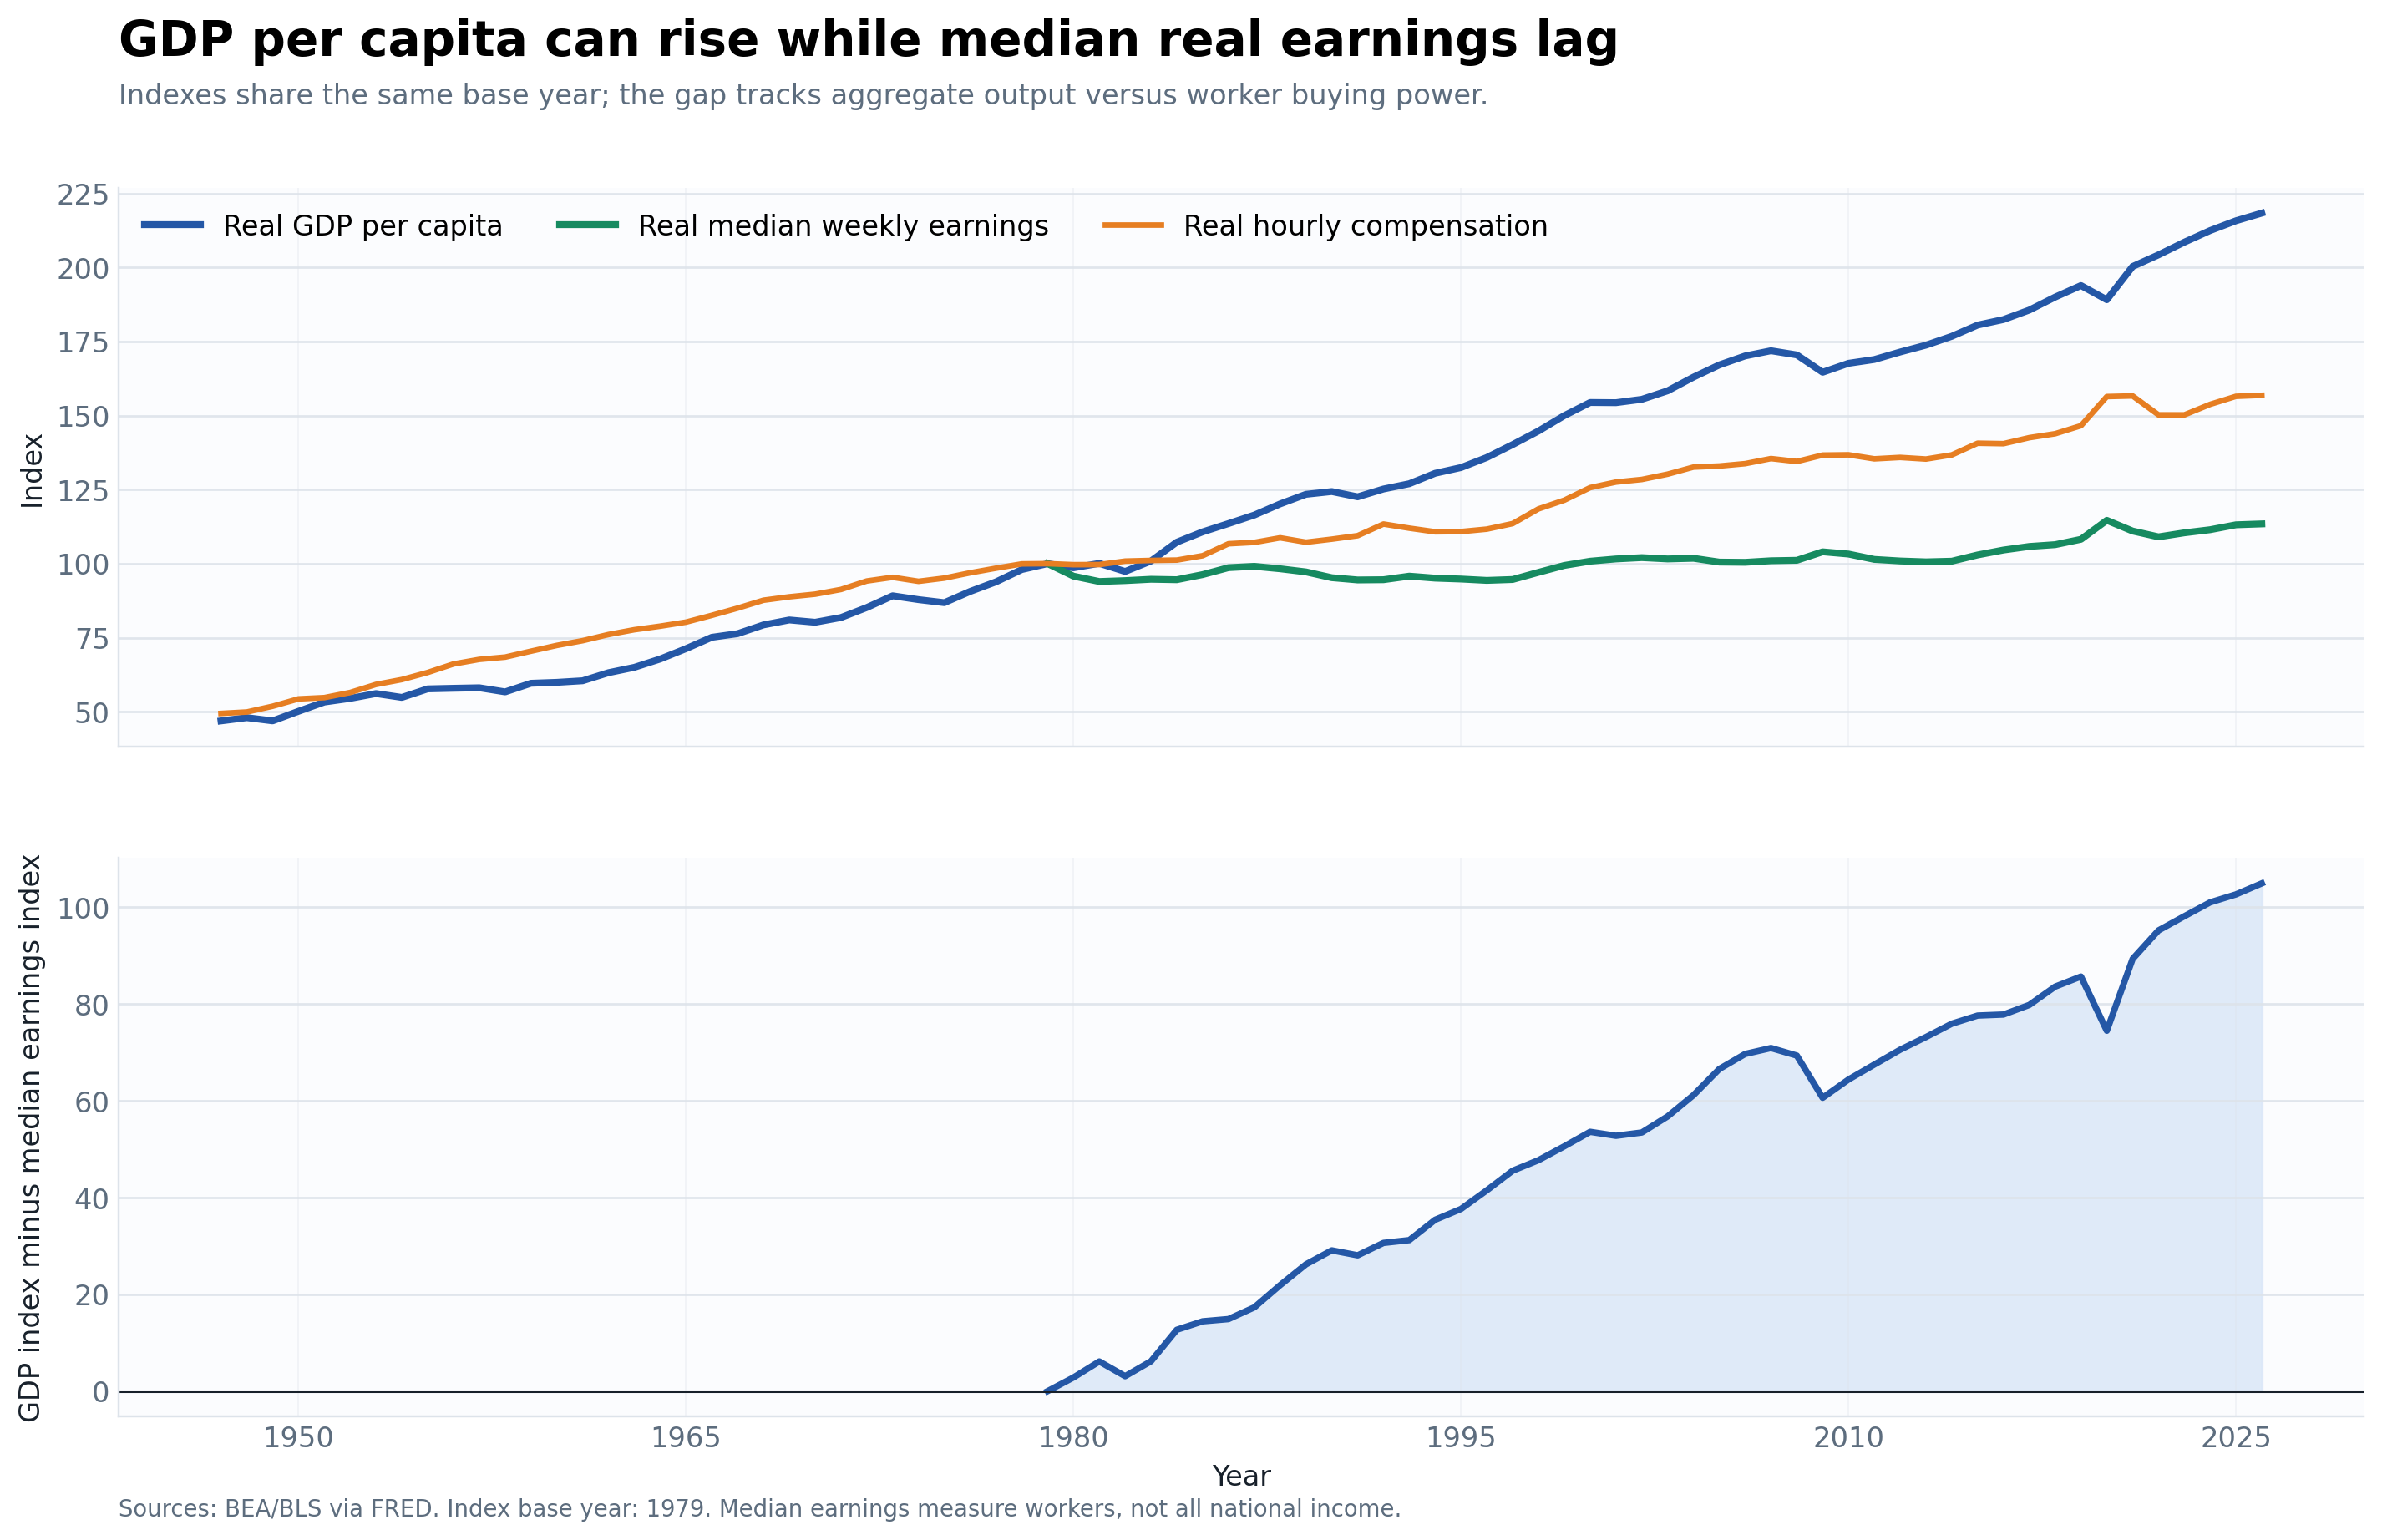

In [5]:
section("GDP per Capita vs Real Wages")
display(Image(filename=str(paths["wage_figure"])))

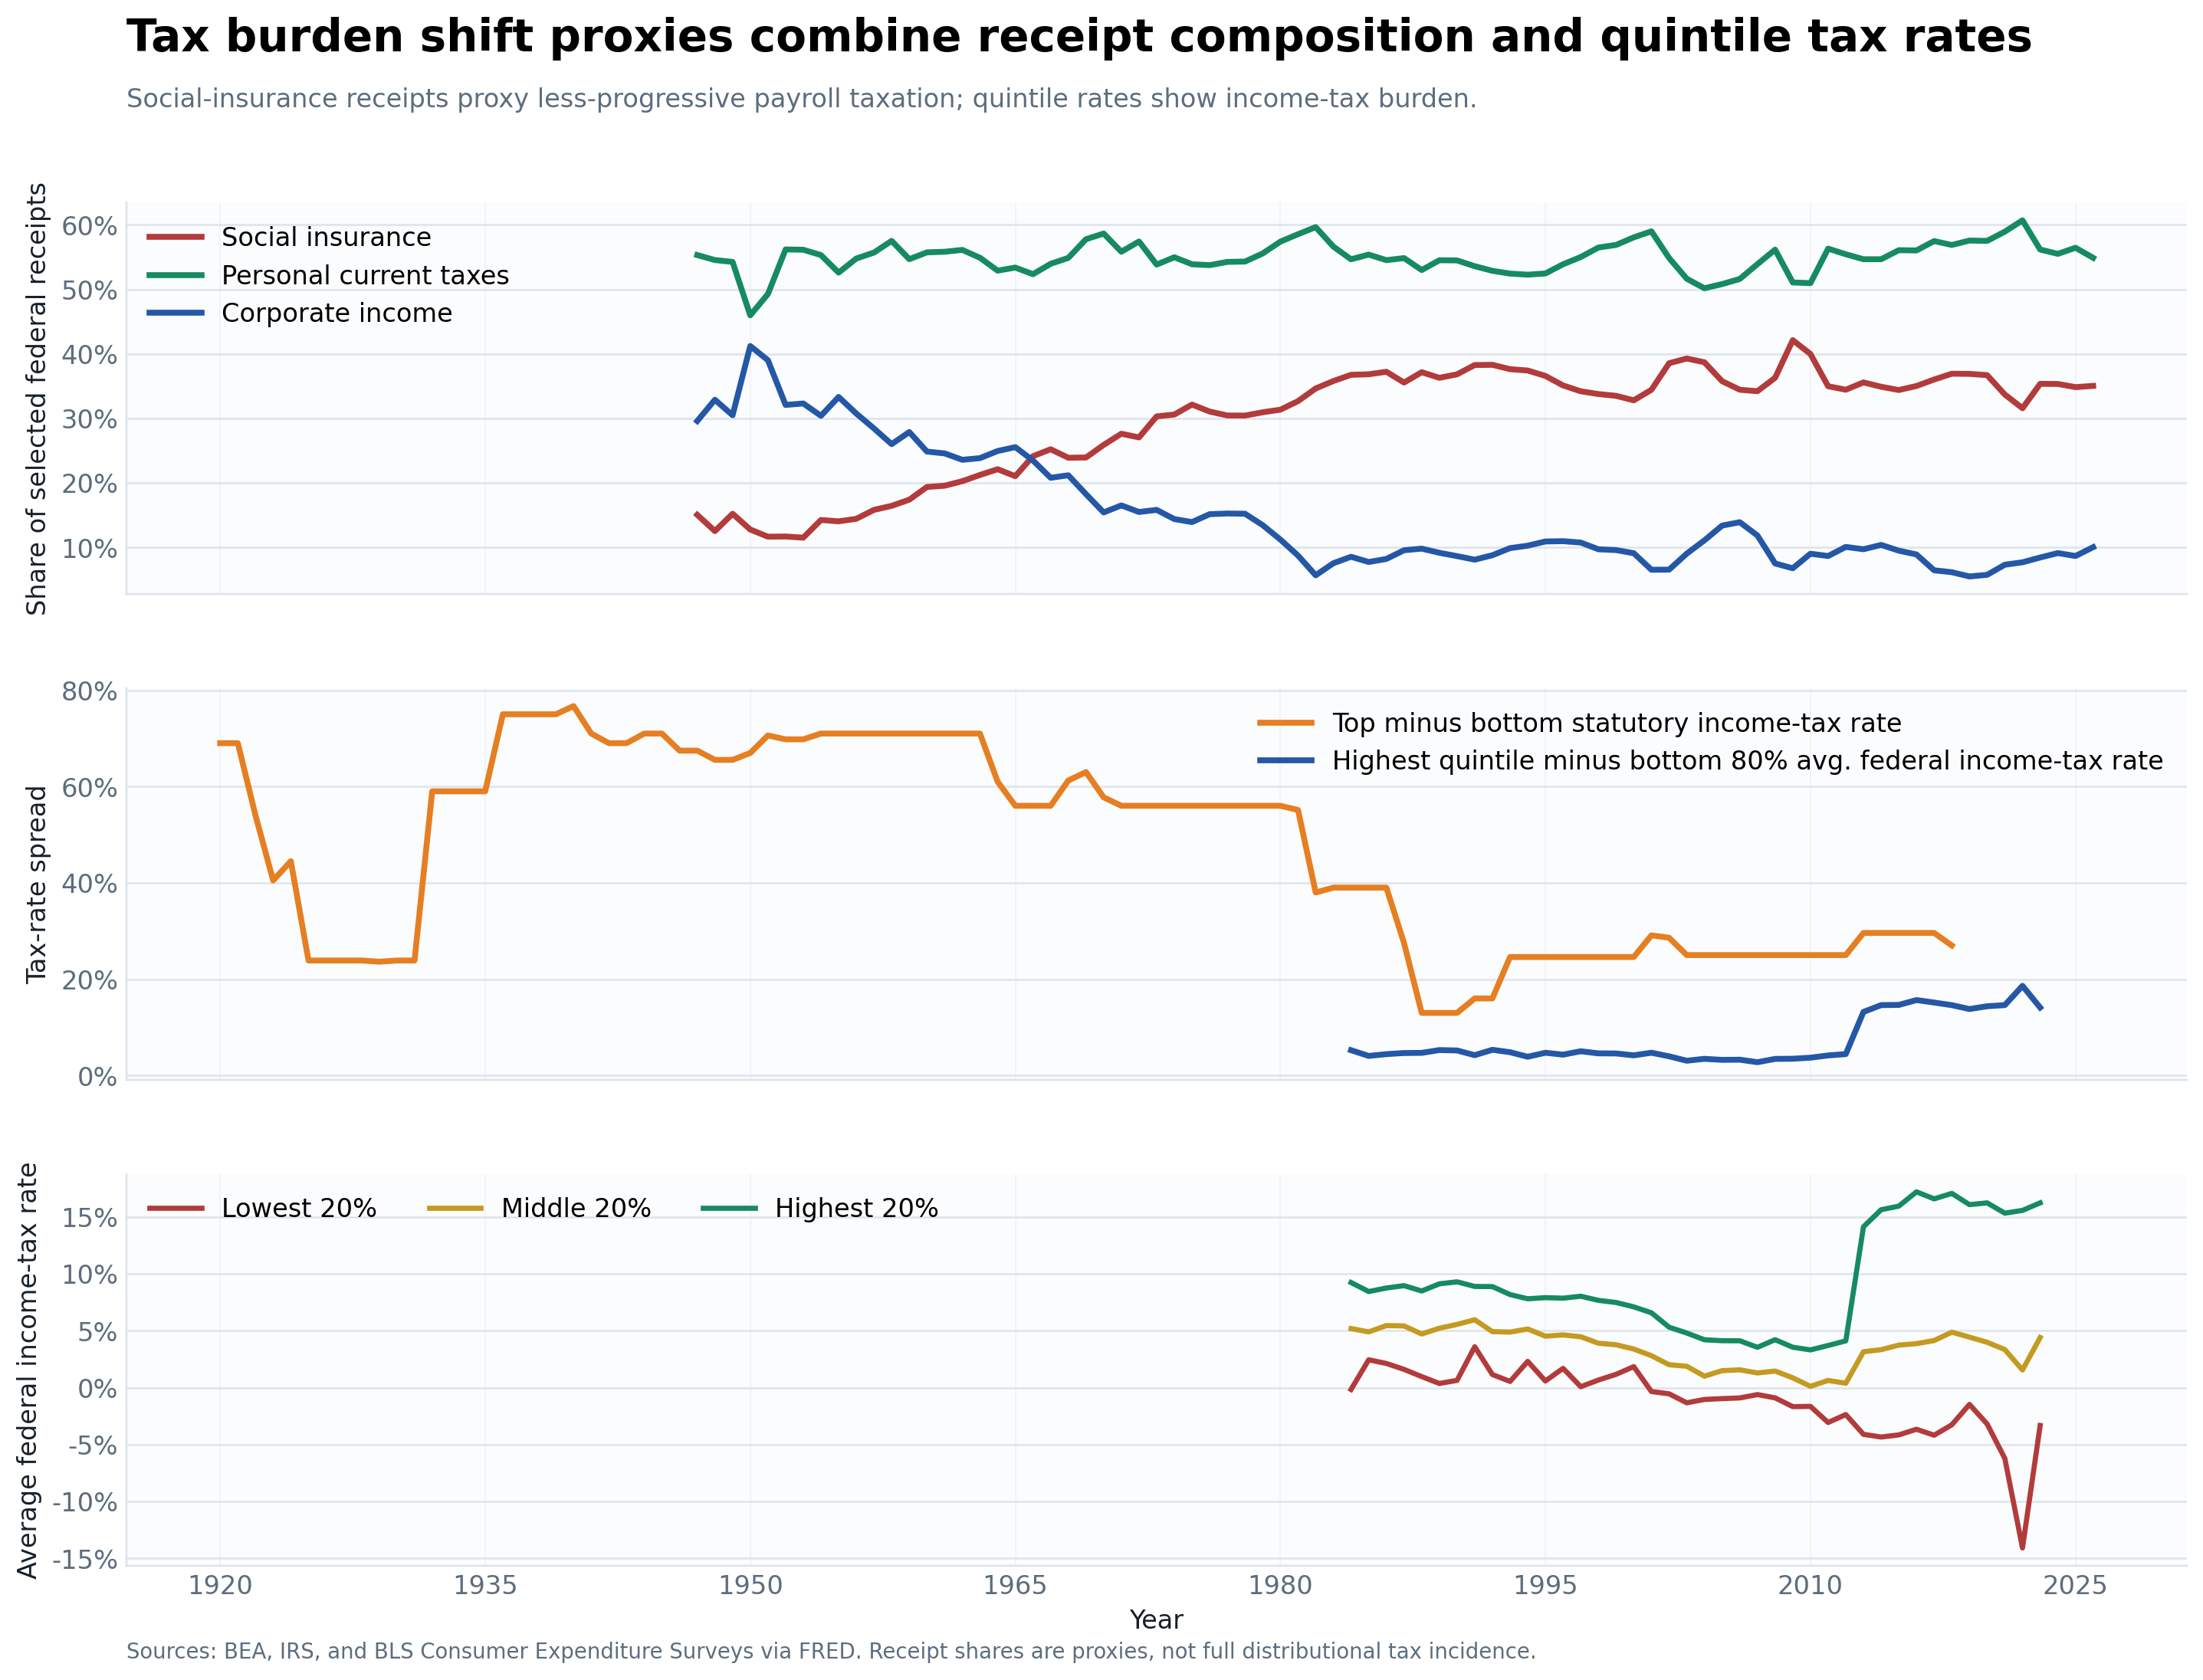

In [6]:
section("Tax Burden Shift Proxies")
display(Image(filename=str(paths["tax_figure"])))

In [7]:
section("Quintile Federal Income-Tax Rates")
quintile_view = quintiles.dropna(subset=["federal_income_tax_rate_q5"]).copy()
for column in [
    "federal_income_tax_rate_q1",
    "federal_income_tax_rate_q2",
    "federal_income_tax_rate_q3",
    "federal_income_tax_rate_q4",
    "federal_income_tax_rate_q5",
    "q5_minus_bottom80_federal_income_tax_rate",
]:
    quintile_view[column] = quintile_view[column].map(lambda value: f"{value:+.2f}%")

display(quintile_view[[
    "year",
    "federal_income_tax_rate_q1",
    "federal_income_tax_rate_q2",
    "federal_income_tax_rate_q3",
    "federal_income_tax_rate_q4",
    "federal_income_tax_rate_q5",
    "q5_minus_bottom80_federal_income_tax_rate",
]].tail(12))

,year,federal_income_tax_rate_q1,federal_income_tax_rate_q2,federal_income_tax_rate_q3,federal_income_tax_rate_q4,federal_income_tax_rate_q5,q5_minus_bottom80_federal_income_tax_rate
92,2012,-2.36%,-1.09%,+0.39%,+1.73%,+4.11%,+4.44%
93,2013,-4.10%,-2.52%,+3.16%,+7.19%,+14.13%,+13.20%
94,2014,-4.34%,-2.69%,+3.33%,+7.75%,+15.63%,+14.61%
95,2015,-4.15%,-2.25%,+3.74%,+7.83%,+15.94%,+14.65%
96,2016,-3.65%,-2.20%,+3.86%,+8.15%,+17.20%,+15.66%
97,2017,-4.18%,-2.27%,+4.14%,+8.05%,+16.58%,+15.15%
98,2018,-3.26%,-0.61%,+4.87%,+8.82%,+17.06%,+14.61%
99,2019,-1.47%,-1.33%,+4.44%,+7.48%,+16.08%,+13.80%
100,2020,-3.19%,-0.67%,+3.99%,+7.29%,+16.23%,+14.38%
101,2021,-6.21%,-1.45%,+3.35%,+7.16%,+15.33%,+14.61%


In [8]:
section("Lagged Association Screen")
assoc_view = associations.copy()
for column in ["coefficient", "std_error", "conf_low", "conf_high"]:
    assoc_view[column] = assoc_view[column].map(lambda value: f"{value:+.3f}")
assoc_view["p_value"] = assoc_view["p_value"].map(lambda value: f"{value:.3f}")
display(assoc_view[[
    "outcome",
    "predictor",
    "lag",
    "coefficient",
    "std_error",
    "p_value",
    "n_observations",
    "r_squared",
]])

,outcome,predictor,lag,coefficient,std_error,p_value,n_observations,r_squared
0,gdp_growth,social_insurance_share,1,-0.055,+0.034,0.101,75,0.040
1,real_median_weekly_earnings_growth,social_insurance_share,1,-0.006,+0.147,0.970,47,0.000
2,gdp_per_capita_minus_median_earnings_index,social_insurance_share,1,+1.416,+2.450,0.563,48,0.012
3,gdp_growth,income_corporate_tax_share,1,+0.055,+0.034,0.101,75,0.040
4,real_median_weekly_earnings_growth,income_corporate_tax_share,1,+0.006,+0.147,0.970,47,0.000
5,gdp_per_capita_minus_median_earnings_index,income_corporate_tax_share,1,-1.416,+2.450,0.563,48,0.012
6,gdp_growth,statutory_rate_spread,1,+0.052,+0.025,0.040,99,0.058
7,real_median_weekly_earnings_growth,statutory_rate_spread,1,-0.020,+0.039,0.611,40,0.019
8,gdp_per_capita_minus_median_earnings_index,statutory_rate_spread,1,-1.200,+0.403,0.003,41,0.253
9,gdp_growth,q5_minus_bottom80_federal_income_tax_rate,1,-0.028,+0.061,0.641,38,0.005


### Reading the Results

- A rising GDP-per-capita index with a flatter median-earnings index means average output can grow faster than the buying power of the median full-time wage worker.
- A rising social-insurance share means more selected federal receipts are coming from payroll/social-insurance channels rather than personal or corporate income-tax channels.
- Negative bottom-quintile federal income-tax rates can occur because refundable credits can exceed income-tax liability.
- The association table is a screen, not causal identification. It asks whether last year's tax-burden proxy lines up with this year's GDP growth, median wage growth, or GDP/wage gap.

### Next Methodological Step

A full version should add CBO effective federal tax rates by income group and separate payroll, individual income, corporate, estate, and excise tax incidence. The current notebook is a defensible first pass because it separates aggregate output from worker buying power and avoids treating statutory rates as the whole tax burden.